# Utility Functions

In [1]:

import matplotlib.pyplot as plt


def unit_vector_2d(theta):
    """ Generates a unit vector with the given angle in radians.

    :param theta: angle in radians
    :return: unit vector
    """
    return np.array([np.cos(theta), np.sin(theta)])


def generate_rotations(v, n, degrees=False):
    """ Generates n rotations around the vector v.

    v: base unit vector of shape (2,)
    n: number of rotations
    degrees: return output_angles in degrees if True

    returns:
        rotated vectors: (n, 2)
        output_angles: (n,)
    """
    v = np.asarray(v, dtype=float)

    # Generate Rotation Matrices & rotate v
    angles = 2 * np.pi * np.arange(n) / n
    cos = np.cos(angles)
    sin = np.sin(angles)
    R = np.stack([
        np.stack([cos, -sin], axis=1),
        np.stack([sin, cos], axis=1)
    ], axis=1)  # (n, 2, 2)
    rotated = R @ v

    angles_out = np.degrees(angles) if degrees else angles
    return rotated, angles_out


def plot_attn_v_angle(attn, angles, degrees=False, y_label="attention (dot product)"):
    """ Plots the attention to angle graph in cartesian coordinates.

    :param attn: attention corresponding to each angle
    :param angles: angles of the vectors
    :param degrees: angles in degrees if True
    :param y_label: label for the attention
    """
    if not degrees:
        x_label = "theta (radians)"
    else:
        x_label = "theta (degrees)"
    plt.figure()
    plt.plot(angles, attn)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title("Attention vs Angle")
    plt.grid(True)
    plt.show()


def plot_attn_v_angle_polar(attn, angles, degrees=False,
                            r_label="attention"):
    """ Plots the attention to angle graph in polar coordinates."""
    if degrees:
        angles = np.deg2rad(angles)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="polar")

    ax.plot(angles, attn)
    ax.set_xlabel("theta")
    ax.set_ylabel(r_label)

    ax.set_title("Attention vs Angle (Polar)")
    ax.grid(True)
    plt.show()

$|a|$
sim(q, k) = e^(q @ k.T)
$\lVert a \rVert$
Observation:
q @ k.T = |q||k|cos(θ)
$a^{(b \cdot c)} \in \mathbb{R}^{N \times M}$
$\cos \theta$
$(q \cdot k)  \in \mathbb{R}$



### Usage

- generate a Unit Vector (usually of angle 0) to act as the query.
- generate N equally rotated versions of the vector around 360 degrees to act as possible keys relative to the query.

Goal, plot the attention between query and key values for the similarity functions.


# 1. Standard Softmax Attention
$$
\mathrm{sim}(q, k) = \exp(q k^\top)
$$
$$
q k^\top = \lVert q \rVert \, \lVert k \rVert \cos(\theta)
$$


when q and k are unit vectors, the attention value is simple the cosine function. when they are not, it is simply scaled
by the product of lengths ($attn(q, k) \propto |q||k|$)

Since $q k^\top  \in \mathbb{R}$, $\exp(q k^\top)$ does not rotate any vectors and simply scales the attention values
independently to ensure all values are positive.


#### 1.1 $q k^\top$

x @ y.T = cos(theta)
since x and y are unit vectors, |x| and |y| is 1.

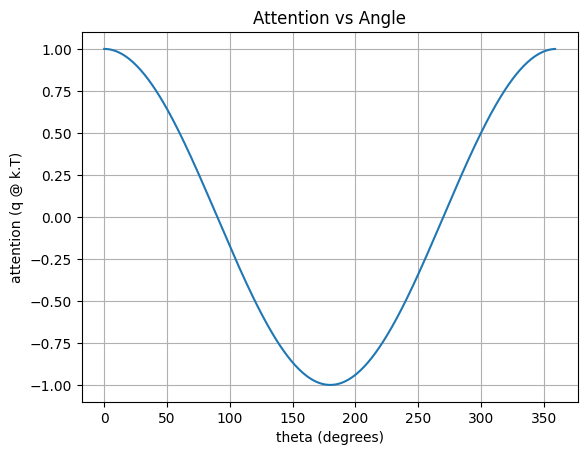

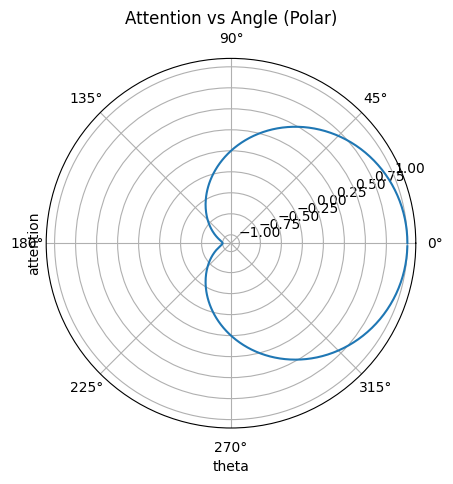

In [2]:
import numpy as np

query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]
attn = np.matmul(query, keys.T)  # [,2] @ [2, 360] = [,360]

plot_attn_v_angle(attn, angles, y_label="attention (q @ k.T)", degrees=True)
plot_attn_v_angle_polar(attn, angles, degrees=True)

#### 1.2 true softmax: $\exp(q k^\top)$

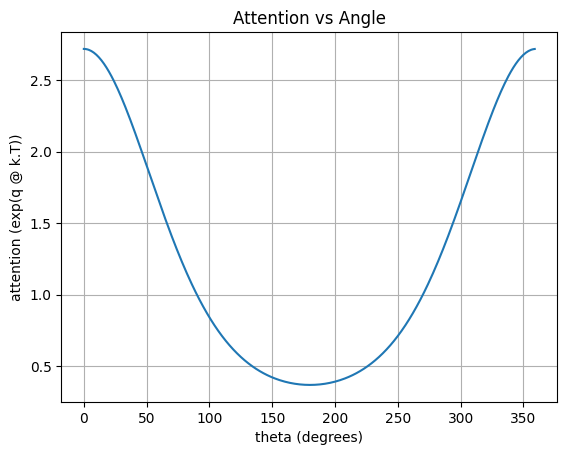

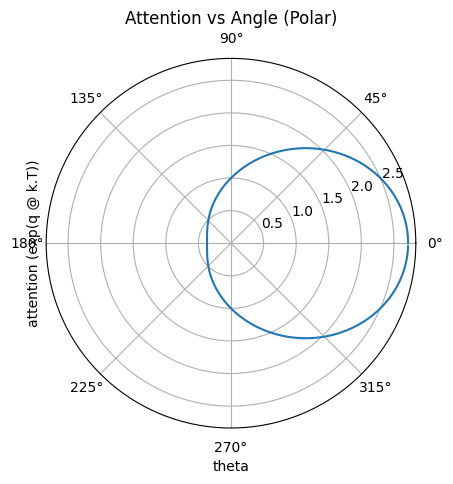

In [3]:
exp_attn = np.exp(attn)
plot_attn_v_angle(exp_attn, angles, y_label="attention (exp(q @ k.T))", degrees=True)
plot_attn_v_angle_polar(exp_attn, angles, degrees=True, r_label="attention (exp(q @ k.T))")

# 2. Linear Attention

$$
\mathrm{sim}(q, k) = \phi(a) \cdot \phi(k)^\top
$$


#### 2.1 (Elu kernel function)

$$
\phi(x) = \alpha (e^{x} - 1)
$$

Observations 1: Attention Values are Rotated when query angles vary
<br>Reason: the exponential function is applied to each dimension instead if the attention value. This would rotate each query and key vector as a side effect.

Hypothesis:
Observation 1 is likely the reason why they dont work well.
Exp is applied to the query and key seperately for each dimension independently. This rotates the query and keys as a side effect.
This means the attention value is measuring alignment between totally different vectors than the original query and keys.
<br><br>
Rotations will always occur as a side effect if the kernel function applies any non-linearity dimension wise.

(360,)


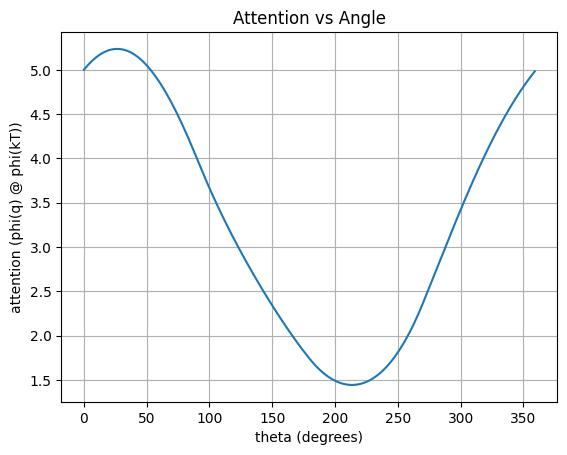

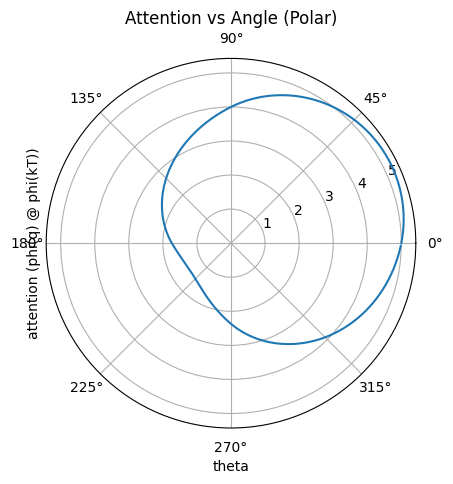

In [4]:
query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]


def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))


phi = lambda x: elu(x) + 1
linear_attn = np.matmul(phi(query), phi(keys.T))
print(linear_attn.shape)
plot_attn_v_angle(linear_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(linear_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")

(360,)


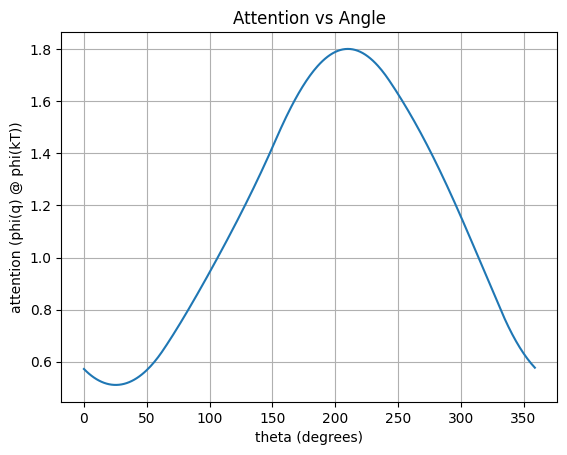

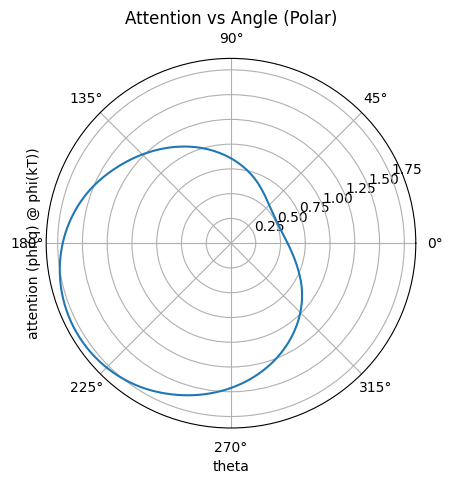

In [5]:
query = unit_vector_2d(theta=2.3 * np.pi / 2)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]


def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))


phi = lambda x: elu(x) + 1
linear_attn = np.matmul(phi(query), phi(keys.T))
print(linear_attn.shape)
plot_attn_v_angle(linear_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(linear_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")

#### 2.1 (Relu kernel function)

$$
\phi(x) = relu(x)
$$

Observations:
- suffers from the same thing as elu
- will break down on certain angles, like 2.3 * np.pi/2

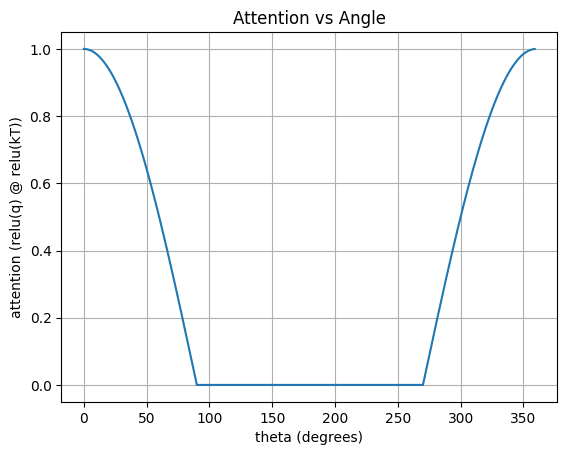

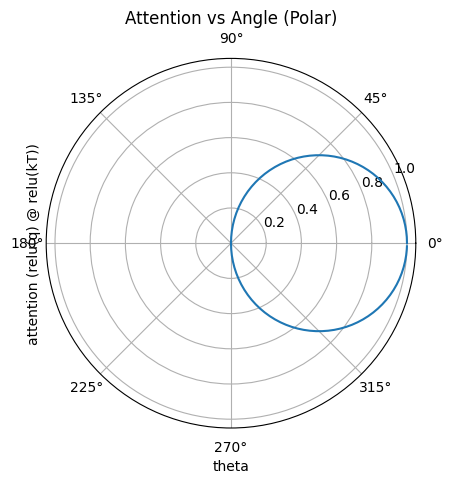

In [6]:
query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]


def relu(x):
    """ReLU feature map."""
    return np.maximum(0, x)


label = "attention (relu(q) @ relu(kT))"
linear_attn = np.matmul(relu(query), relu(keys.T))
plot_attn_v_angle(linear_attn, angles, y_label=label, degrees=True)
plot_attn_v_angle_polar(linear_attn, angles, degrees=True, r_label=label)

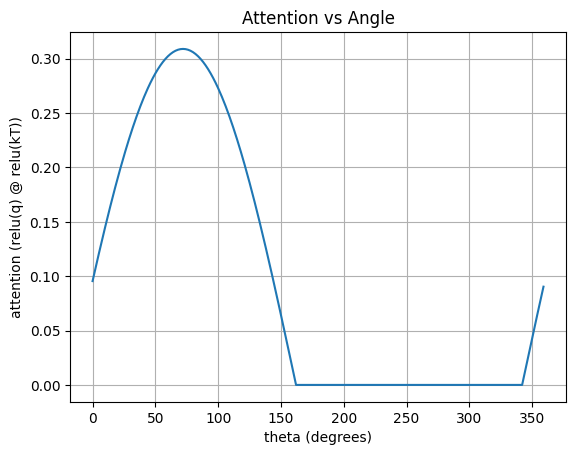

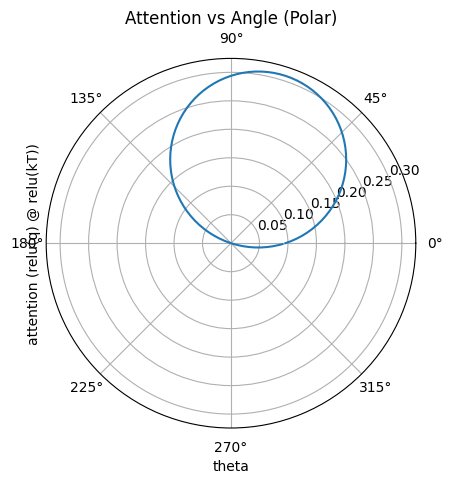

In [7]:
query = unit_vector_2d(theta=3.2 * np.pi / 2)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]


def relu(x):
    """ReLU feature map."""
    return np.maximum(0, x)


label = "attention (relu(q) @ relu(kT))"
linear_attn = np.matmul(relu(query), relu(keys.T))
plot_attn_v_angle(linear_attn, angles, y_label=label, degrees=True)
plot_attn_v_angle_polar(linear_attn, angles, degrees=True, r_label=label)

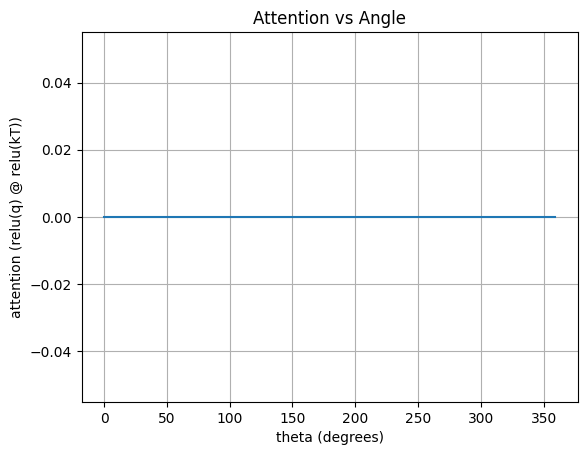

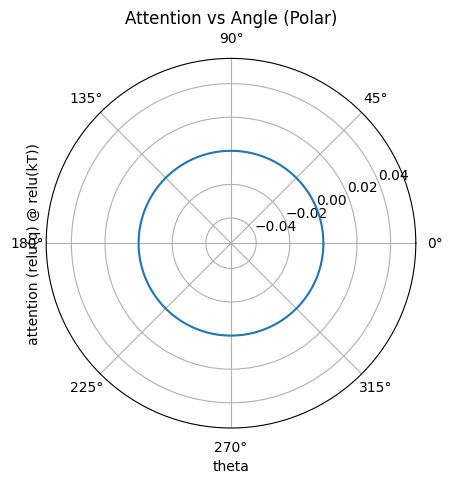

In [8]:
query = unit_vector_2d(theta=2.3 * np.pi / 2)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]


def relu(x):
    """ReLU feature map."""
    return np.maximum(0, x)


label = "attention (relu(q) @ relu(kT))"
linear_attn = np.matmul(relu(query), relu(keys.T))
plot_attn_v_angle(linear_attn, angles, y_label=label, degrees=True)
plot_attn_v_angle_polar(linear_attn, angles, degrees=True, r_label=label)

#### 2.1 Exact taylor expansion (truncated)

- this computes the exact approximation of the softmax function, but is computationally infeasibly.

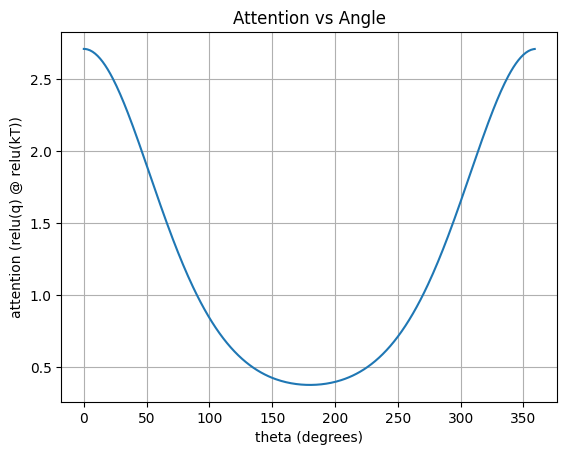

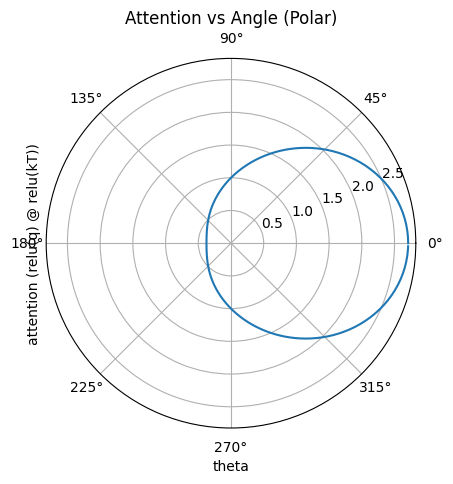

In [9]:
import numpy as np
from math import factorial, sqrt


def taylor_kernel_phi_2d(x, order=4):
    """
    Truncated 2D Taylor expansion feature map for e^{x^T y}.
    """
    x1, x2 = x
    phi = []
    for k in range(order + 1):
        for m in range(order + 1 - k):
            phi.append((x1 ** k) * (x2 ** m) / sqrt(factorial(k) * factorial(m)))
    return np.array(phi)


phi_query = query.reshape(1, 2)  # shape (1,2)
phi_query = np.array([taylor_kernel_phi_2d(q) for q in phi_query])  # shape (num_queries, feature_dim)
phi_keys = np.array([taylor_kernel_phi_2d(k) for k in keys])  # shape (num_keys, feature_dim)
linear_attn = phi_query @ phi_keys.T  # shape (num_queries, num_keys)

linear_attn = linear_attn.flatten()
plot_attn_v_angle(linear_attn, angles, y_label=label, degrees=True)
plot_attn_v_angle_polar(linear_attn, angles, degrees=True, r_label=label)

# Idea:
- instead of trying to approximate the exact attention, we choose a similarity function that performs similarly to it.
- the essense of the similarity value comes from measuring the cosine of the relative angle of the query and key.

# What should make a good similarity function
Let query and key be unit vectors.
1. it does not change the relative angle between query and keys.
2. the highest attention value occurs when the angle is 0
3. the lowest attention value occurs when the angle is 180
4. there is no extrema anywhere else
5. the attention map should scale with the length of query and keys

# Propososition: Vector Norm as the attention value



$$
sim(q, k) = |q + k|^2
$$

$$
|q + k|^2 = |q|^2 + |k|^2 + 2qk^T
$$


Another view is that qk^T is simply the same as standard attention, however, instead of using exp(x) as the scaling function, we scale it by f(x) = |q|^2 + |k|^2 + 2x.


#### 1. |q + k|

Note: when q and k are unit vectors, $|q+k| = 2\cos(\theta / 2)$

(2,)
(360, 2)
(360,)


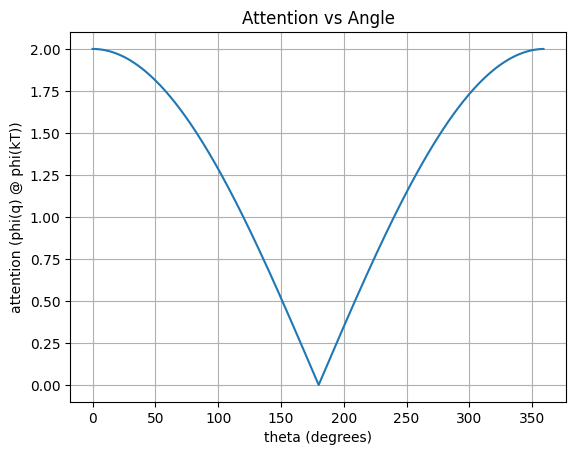

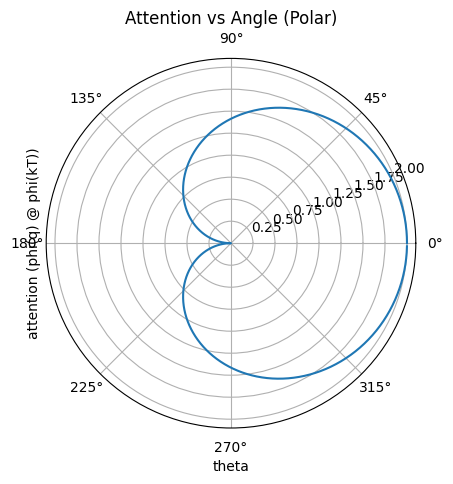

In [10]:
import numpy as np

query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]
q_norm = query
k_norm = keys
# q_norm *= 2.0
# k_norm *= 2.0

norm_attn = np.linalg.norm(q_norm + k_norm, ord=2, axis=-1)
# norm_attn /= 2

print(q_norm.shape)
print(k_norm.shape)
print(norm_attn.shape)

plot_attn_v_angle(norm_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(norm_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")

#### 1. |q + k|^2

- by squaring, we dont need to perform the square root
- it also smoothes the groove

(2,)
(360, 2)
(360,)


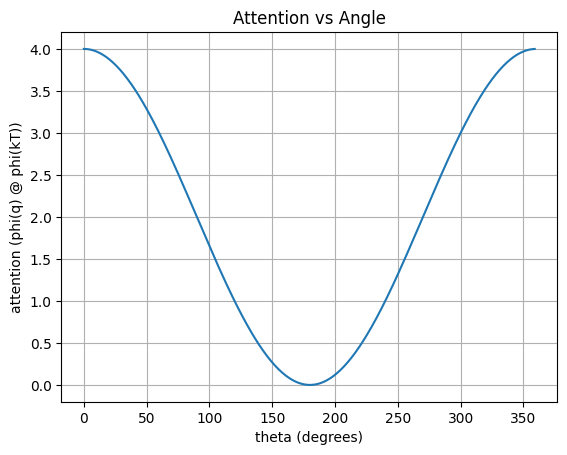

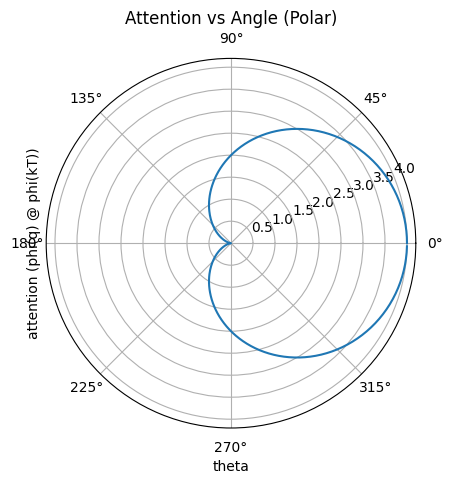

In [11]:
query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]
q_norm = query
k_norm = keys
# q_norm *= 2.0
# k_norm *= 2.0

norm_attn = ((q_norm + k_norm) ** 2).sum(-1)

print(q_norm.shape)
print(k_norm.shape)
print(norm_attn.shape)

plot_attn_v_angle(norm_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(norm_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")

One property I found is that by making the similarity function as length of vectors, I can compute the sum of the attention rows seperately.
This would decouple the row of attention values in the softmax mechanism.

Edit: Z below refers to Z_i<br>
<img src="assets/z_calculation.png" width=70% height=auto><br>


(2,)
(360, 2)
(360,)


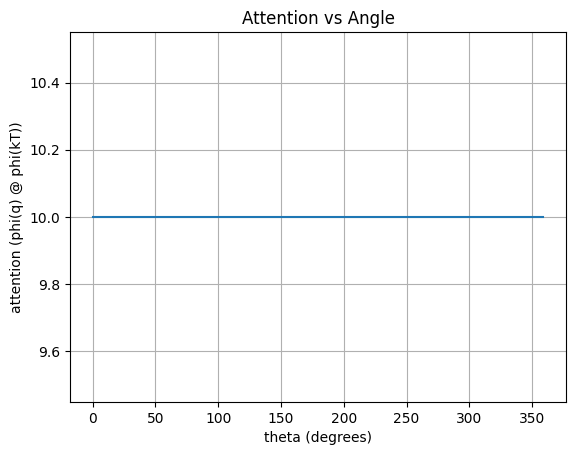

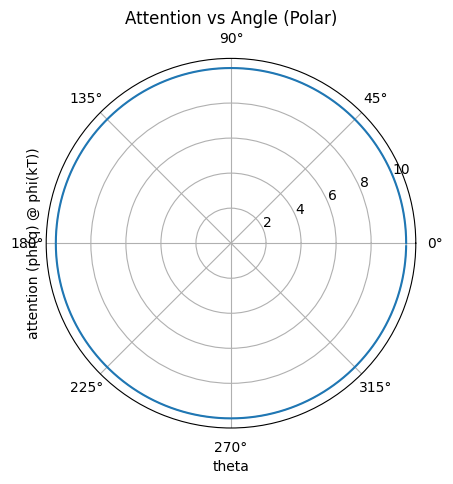

In [16]:
query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]
q_norm = query * 2
k_norm = keys * 3.2

norm_attn = (((q_norm + k_norm) ** 2) + ((q_norm - k_norm) ** 2)).sum(-1)

print(q_norm.shape)
print(k_norm.shape)
print(norm_attn.shape)

plot_attn_v_angle(norm_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(norm_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")

0.9999999999999999
1.0
1.0
(2,)
(360, 2)
(360,)


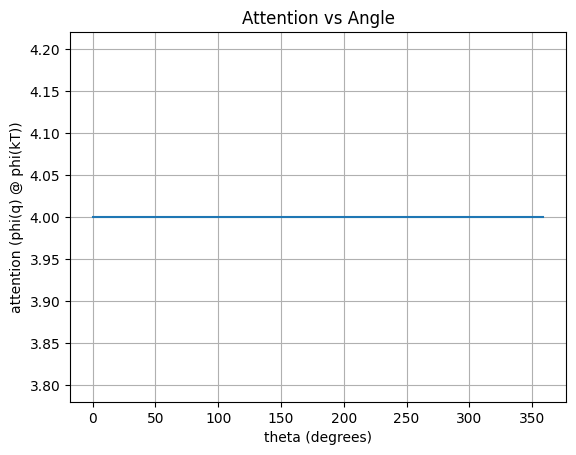

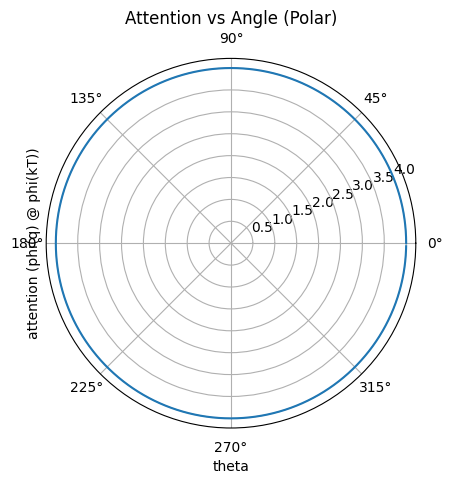

In [33]:
query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]
q_norm = query
k_norm = keys

norm = lambda x, y: ((x + y) ** 2).sum(-1)
zp = norm(q_norm, k_norm)
zn = norm(q_norm, -k_norm)
norm_attn = zp + zn

print((zp / zp.sum(-1, keepdims=True)).sum(-1))
print((zn / zn.sum(-1, keepdims=True)).sum(-1))
print(((zp + zn) / (zp + zn).sum(-1)).sum(-1))
print(q_norm.shape)
print(k_norm.shape)
print(norm_attn.shape)

plot_attn_v_angle(norm_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(norm_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")

# Approximating exp

(2,)
(360, 2)
(360,)


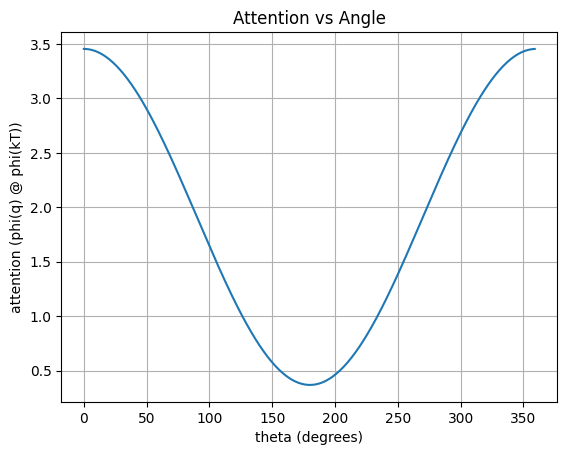

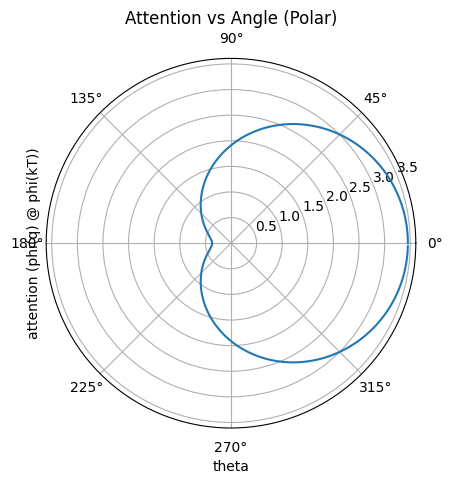

In [14]:
query = unit_vector_2d(theta=0)  # [2]
keys, angles = generate_rotations(query, 360, degrees=True)  # [360, 2]
q_norm = query
k_norm = keys
# q_norm *= 2.0
# k_norm *= 2.0

norm_attn = (((np.exp(1) + np.exp(-1)) / 4) * (q_norm + k_norm) ** 2).sum(-1) + np.exp(-1)

print(q_norm.shape)
print(k_norm.shape)
print(norm_attn.shape)

plot_attn_v_angle(norm_attn, angles, y_label="attention (phi(q) @ phi(kT))", degrees=True)
plot_attn_v_angle_polar(norm_attn, angles, degrees=True, r_label="attention (phi(q) @ phi(kT))")